In [23]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore')

from prophet import Prophet

In [24]:
csv_files = glob.glob('./past/*.csv')

dataframes = []
df = []

for file in csv_files:
    df = pd.read_csv(file, encoding='cp949')
    dataframes.append(df)

combined_dataframe = pd.concat(dataframes, axis=0)

combined_dataframe.head()

,기관 명,모델명,시리얼,서버타입,사이트명,방문자수,날짜,등록일자
0,서울시,SDOT001,2993,00Original,2993,198,202012000000.0,2020-12-28 0:01
1,서울시,SDOT001,2992,00Original,2992,195,202012000000.0,2020-12-28 0:01
2,서울시,SDOT001,2995,00Original,2995,163,202012000000.0,2020-12-28 0:01
3,서울시,SDOT001,2994,00Original,2994,114,202012000000.0,2020-12-28 0:01
4,서울시,SDOT001,2996,00Original,2996,108,202012000000.0,2020-12-28 0:01


In [25]:
combined_dataframe = combined_dataframe[['시리얼', '사이트명', '방문자수', '등록일자']]

In [26]:
combined_dataframe

,시리얼,사이트명,방문자수,등록일자
0,2993,2993,198,2020-12-28 0:01
1,2992,2992,195,2020-12-28 0:01
2,2995,2995,163,2020-12-28 0:01
3,2994,2994,114,2020-12-28 0:01
4,2996,2996,108,2020-12-28 0:01
...,...,...,...,...
102284,4007,4007,3,2021-03-28 23:57
102285,4040,4040,6,2021-03-28 23:57
102286,4020,4020,3,2021-03-28 23:57
102287,4042,4042,10,2021-03-28 23:57


In [27]:
csv_files = glob.glob('./past2/*.csv')

dataframes = []
df = []

for file in csv_files:
    df = pd.read_csv(file, encoding='cp949')
    dataframes.append(df)

combined_dataframe2 = pd.concat(dataframes, axis=0)

combined_dataframe2.head()

기관 명         모델명   시리얼  서버타입          사이트명                 방문자수  \
서울시 SDOT001  4015  00Original  4015   150  202212261100  2022-12-26 11:03:39   
    SDOT001  3009  00Original  3009   231  202212261050  2022-12-26 11:03:39   
    SDOT001  3007  00Original  3007   177  202212261050  2022-12-26 11:03:39   
    SDOT001  4041  00Original  4041    19  202212261100  2022-12-26 11:03:39   
    SDOT001  3004  00Original  3004   208  202212261050  2022-12-26 11:03:40   

             날짜  등록일자  
서울시 SDOT001 NaN   NaN  
    SDOT001 NaN   NaN  
    SDOT001 NaN   NaN  
    SDOT001 NaN   NaN  
    SDOT001 NaN   NaN

In [28]:
combined_dataframe2 = combined_dataframe2[['기관 명', '시리얼', '서버타입', '방문자수']]
combined_dataframe2.columns = ['시리얼', '사이트명', '방문자수', '등록일자']

In [29]:
combined_dataframe2 = combined_dataframe2.reset_index(drop=True)

In [30]:
combined_dataframe2

,시리얼,사이트명,방문자수,등록일자
0,4015,4015,150,2022-12-26 11:03:39
1,3009,3009,231,2022-12-26 11:03:39
2,3007,3007,177,2022-12-26 11:03:39
3,4041,4041,19,2022-12-26 11:03:39
4,3004,3004,208,2022-12-26 11:03:40
...,...,...,...,...
3783837,4030,4030,0,2022-01-16 23:57:23
3783838,4007,4007,4,2022-01-16 23:57:29
3783839,4040,4040,9,2022-01-16 23:57:42
3783840,4042,4042,1,2022-01-16 23:57:48


In [31]:
ppl = pd.concat([combined_dataframe, combined_dataframe2])

In [32]:
ppl = ppl.dropna(axis = 0)


In [33]:
ppl.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9738573 entries, 0 to 3783841
Data columns (total 4 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   시리얼     object
 1   사이트명    object
 2   방문자수    object
 3   등록일자    object
dtypes: object(4)
memory usage: 371.5+ MB


In [34]:
ppl[ppl['등록일자'] == '등록일자']
ppl.reset_index(inplace=True)
ppl.drop(5409077, inplace=True)
ppl.drop(5502009, inplace=True)
ppl.drop('index', axis=1, inplace=True)

In [35]:
ppl['등록일자'] = pd.to_datetime(ppl['등록일자'].str.strip())
ppl['등록일자'] = ppl['등록일자'].dt.floor('H')

In [36]:
ppl = ppl[ppl['시리얼'].isin([4013, 4046, 4009, 4008, 4010, 3020])]

In [37]:
ppl.drop('사이트명', axis=1, inplace=True)

In [38]:
ppl

,시리얼,방문자수,등록일자
29,3020,230,2020-12-28 00:00:00
78,3020,236,2020-12-28 00:00:00
128,3020,198,2020-12-28 00:00:00
178,3020,158,2020-12-28 00:00:00
228,3020,200,2020-12-28 00:00:00
...,...,...,...
9738492,4008,3,2022-01-16 23:00:00
9738521,3020,337,2022-01-16 23:00:00
9738552,4010,17,2022-01-16 23:00:00
9738558,4009,13,2022-01-16 23:00:00


In [39]:
mapping_dict = {
    4013: '압구정',
    4046: '신사',
    4009: '선릉',
    4008: '선릉',
    3020: '신논현',
    4010: '신논현'
}

ppl['지역명'] = ppl['시리얼'].map(mapping_dict)


In [40]:
ppl = ppl[ppl['방문자수']!='00000000-2']
ppl = ppl[ppl['방문자수']!='00000000-1']

In [41]:
ppl['방문자수'] = ppl['방문자수'].astype(int)

In [42]:
ppl = ppl.groupby(['등록일자', '지역명'])['방문자수'].sum().reset_index()

In [43]:
# ppl[ppl['time']=='2022-12-09 23:00:00']

In [44]:
(790+52)/2

421.0

In [45]:
df = pd.read_html('./20-22 강남구 전체 음주운전 사고.xls')

In [46]:
df

[                 사고번호               사고일시   요일             시군구  사고내용  사망자수  \
 0    2020010200100017    2020년 1월 2일 03시  목요일  서울특별시 강남구 압구정동  경상사고     0   
 1    2020010300100014    2020년 1월 3일 01시  금요일   서울특별시 강남구 청담동  경상사고     0   
 2    2020010300100116    2020년 1월 3일 09시  금요일   서울특별시 강남구 도곡동  경상사고     0   
 3    2020010300100266    2020년 1월 3일 14시  금요일   서울특별시 강남구 삼성동  중상사고     0   
 4    2020010400100046    2020년 1월 4일 03시  토요일   서울특별시 강남구 논현동  경상사고     0   
 ..                ...                ...  ...             ...   ...   ...   
 987  2022122400100037  2022년 12월 24일 03시  토요일   서울특별시 강남구 청담동  경상사고     0   
 988  2022122500100001  2022년 12월 25일 00시  일요일   서울특별시 강남구 역삼동  경상사고     0   
 989  2022122700100027  2022년 12월 27일 03시  화요일   서울특별시 강남구 삼성동  중상사고     0   
 990  2022123000100493  2022년 12월 30일 18시  금요일   서울특별시 강남구 신사동  중상사고     0   
 991  2022123000100626  2022년 12월 30일 21시  금요일   서울특별시 강남구 삼성동  경상사고     0   
 
      중상자수  경상자수  부상신고자수        사고유형  ... 기상상태         도로형태 가해

In [47]:
accident = df[0]

accident = accident.iloc[:, 1:9]
accident.drop('사고내용', axis=1,inplace=True)
accident['ECLO'] = (10*accident['사망자수']) + (5*accident['중상자수']) + (3*accident['경상자수']) + accident['부상신고자수']
accident['time'] = pd.to_datetime(accident['사고일시'], format="%Y년 %m월 %d일 %H시")
accident.drop('사고일시', axis=1, inplace=True)

In [48]:
accident['시군구'].unique()

array(['서울특별시 강남구 압구정동', '서울특별시 강남구 청담동', '서울특별시 강남구 도곡동',
       '서울특별시 강남구 삼성동', '서울특별시 강남구 논현동', '서울특별시 강남구 개포동', '서울특별시 강남구 역삼동',
       '서울특별시 강남구 신사동', '서울특별시 강남구 대치동', '서울특별시 강남구 수서동', '서울특별시 강남구 일원동',
       '서울특별시 강남구 세곡동', '서울특별시 강남구 자곡동', '서울특별시 강남구 율현동'], dtype=object)

In [49]:
mapping_dict = {
    '청담동': '청담동',
    '논현동': '논현동',
    '신사동': '신사동',
    '역삼동': '역삼동'
}

def map_values(row):
    for key in mapping_dict:
        if key in row['시군구']:
            return mapping_dict[key]
    return "Other"  # 매핑 사전에 없는 경우 'Other'로 분류

accident['지역명'] = accident.apply(map_values, axis=1)

In [50]:
accident

,요일,시군구,사망자수,중상자수,경상자수,부상신고자수,ECLO,time,지역명
0,목요일,서울특별시 강남구 압구정동,0,0,2,0,6,2020-01-02 03:00:00,Other
1,금요일,서울특별시 강남구 청담동,0,0,2,0,6,2020-01-03 01:00:00,청담동
2,금요일,서울특별시 강남구 도곡동,0,0,1,0,3,2020-01-03 09:00:00,Other
3,금요일,서울특별시 강남구 삼성동,0,1,2,0,11,2020-01-03 14:00:00,Other
4,토요일,서울특별시 강남구 논현동,0,0,1,0,3,2020-01-04 03:00:00,논현동
...,...,...,...,...,...,...,...,...,...
987,토요일,서울특별시 강남구 청담동,0,0,2,0,6,2022-12-24 03:00:00,청담동
988,일요일,서울특별시 강남구 역삼동,0,0,2,0,6,2022-12-25 00:00:00,역삼동
989,화요일,서울특별시 강남구 삼성동,0,1,0,0,5,2022-12-27 03:00:00,Other
990,금요일,서울특별시 강남구 신사동,0,1,5,0,20,2022-12-30 18:00:00,신사동


In [51]:
accident = accident[accident['지역명']!='Other']

In [52]:
accident

,요일,시군구,사망자수,중상자수,경상자수,부상신고자수,ECLO,time,지역명
1,금요일,서울특별시 강남구 청담동,0,0,2,0,6,2020-01-03 01:00:00,청담동
4,토요일,서울특별시 강남구 논현동,0,0,1,0,3,2020-01-04 03:00:00,논현동
5,토요일,서울특별시 강남구 논현동,0,0,1,0,3,2020-01-04 08:00:00,논현동
7,일요일,서울특별시 강남구 역삼동,0,1,4,0,17,2020-01-05 10:00:00,역삼동
9,월요일,서울특별시 강남구 역삼동,0,0,0,1,1,2020-01-06 23:00:00,역삼동
...,...,...,...,...,...,...,...,...,...
985,목요일,서울특별시 강남구 논현동,0,0,1,0,3,2022-12-22 06:00:00,논현동
986,토요일,서울특별시 강남구 신사동,0,0,3,0,9,2022-12-24 00:00:00,신사동
987,토요일,서울특별시 강남구 청담동,0,0,2,0,6,2022-12-24 03:00:00,청담동
988,일요일,서울특별시 강남구 역삼동,0,0,2,0,6,2022-12-25 00:00:00,역삼동


In [74]:
accident

,region,요일,시군구,ECLO,time
0,압구정,목요일,서울특별시 강남구 압구정동,6,2020-01-02 03:00:00
1,압구정,수요일,서울특별시 강남구 신사동,9,2020-01-22 00:00:00
2,압구정,목요일,서울특별시 강남구 청담동,5,2020-01-23 01:00:00
3,압구정,금요일,서울특별시 강남구 신사동,3,2020-02-07 21:00:00
4,압구정,일요일,서울특별시 강남구 청담동,6,2020-02-09 02:00:00
...,...,...,...,...,...
174,선릉,수요일,서울특별시 강남구 삼성동,9,2022-12-14 02:00:00
175,선릉,목요일,서울특별시 강남구 역삼동,3,2022-12-15 07:00:00
176,선릉,월요일,서울특별시 강남구 논현동,6,2022-12-19 23:00:00
177,선릉,일요일,서울특별시 강남구 역삼동,6,2022-12-25 00:00:00


In [53]:
ppl

,등록일자,지역명,방문자수
0,2020-05-04 00:00:00,신논현,1410
1,2020-05-04 01:00:00,신논현,1027
2,2020-05-04 02:00:00,신논현,712
3,2020-05-04 03:00:00,신논현,676
4,2020-05-04 04:00:00,신논현,604
...,...,...,...
67957,2022-12-28 22:00:00,압구정,441
67958,2022-12-28 23:00:00,선릉,614
67959,2022-12-28 23:00:00,신논현,770
67960,2022-12-28 23:00:00,신사,141


In [54]:
ap = pd.read_html('./accident/로데오.xls')
ap = ap[0]
ap['region'] = '압구정'

ss = pd.read_html('./accident/신사.xls')
ss = ss[0]
ss['region'] = '신사'

cd = pd.read_html('./accident/청담.xls')
cd = cd[0]
cd['region'] = '청담'

sn = pd.read_html('./accident/신논현.xls')
sn = sn[0]
sn['region'] = '신논현'

sl = pd.read_html('./accident/선릉.xls')
sl = sl[0]
sl['region'] = '선릉'

df = pd.concat([ap, ss, cd, sn, sl])

In [55]:
cols = df.columns.tolist() 
new_cols = [cols[-1]] + cols[:-1] 

accident = df[new_cols]

In [77]:
accident

,region,요일,시군구,ECLO,time
0,압구정,목요일,서울특별시 강남구 압구정동,6,2020-01-02 03:00:00
1,압구정,수요일,서울특별시 강남구 신사동,9,2020-01-22 00:00:00
2,압구정,목요일,서울특별시 강남구 청담동,5,2020-01-23 01:00:00
3,압구정,금요일,서울특별시 강남구 신사동,3,2020-02-07 21:00:00
4,압구정,일요일,서울특별시 강남구 청담동,6,2020-02-09 02:00:00
...,...,...,...,...,...
174,선릉,수요일,서울특별시 강남구 삼성동,9,2022-12-14 02:00:00
175,선릉,목요일,서울특별시 강남구 역삼동,3,2022-12-15 07:00:00
176,선릉,월요일,서울특별시 강남구 논현동,6,2022-12-19 23:00:00
177,선릉,일요일,서울특별시 강남구 역삼동,6,2022-12-25 00:00:00


(array([130.,  95.,   0., 102.,   0.,  87., 120.,   0., 101.,  66.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

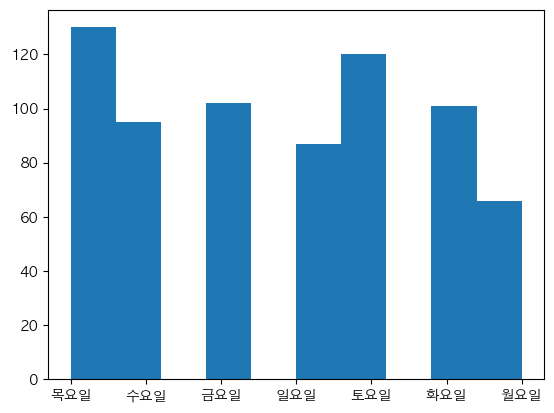

In [79]:
import matplotlib.pyplot as plt 
from matplotlib import rc
import seaborn as sns
%matplotlib inline

rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

plt.hist(accident['요일'])

In [57]:
accident = accident.iloc[:,:10]
accident.drop('사고내용', axis=1,inplace=True)
accident.drop('사고번호', axis=1,inplace=True)
accident['ECLO'] = (10*accident['사망자수']) + (5*accident['중상자수']) + (3*accident['경상자수']) + accident['부상신고자수']
accident['time'] = pd.to_datetime(accident['사고일시'], format="%Y년 %m월 %d일 %H시")
accident.drop('사고일시', axis=1, inplace=True)
accident.drop('사망자수', axis=1,inplace=True)
accident.drop('중상자수', axis=1,inplace=True)
accident.drop('경상자수', axis=1,inplace=True)
accident.drop('부상신고자수', axis=1,inplace=True)

In [75]:
accident

,region,요일,시군구,ECLO,time
0,압구정,목요일,서울특별시 강남구 압구정동,6,2020-01-02 03:00:00
1,압구정,수요일,서울특별시 강남구 신사동,9,2020-01-22 00:00:00
2,압구정,목요일,서울특별시 강남구 청담동,5,2020-01-23 01:00:00
3,압구정,금요일,서울특별시 강남구 신사동,3,2020-02-07 21:00:00
4,압구정,일요일,서울특별시 강남구 청담동,6,2020-02-09 02:00:00
...,...,...,...,...,...
174,선릉,수요일,서울특별시 강남구 삼성동,9,2022-12-14 02:00:00
175,선릉,목요일,서울특별시 강남구 역삼동,3,2022-12-15 07:00:00
176,선릉,월요일,서울특별시 강남구 논현동,6,2022-12-19 23:00:00
177,선릉,일요일,서울특별시 강남구 역삼동,6,2022-12-25 00:00:00


In [59]:
ppl.columns = ['time', 'region', '방문자수']

In [60]:
fin = pd.merge(accident, ppl, on=['time', 'region'], how='left')

In [61]:
# 608 rows

fin = fin[fin['time'] >= '2020-05-03']

In [62]:
final = fin[fin['region']!='청담']
ch = fin[fin['region']=='청담']
ch.drop('방문자수', axis=1, inplace=True)

In [63]:
chppl = ppl[ppl['region']=='압구정']
chppl['region'] = '청담'
ch = pd.merge(ch, chppl, on=['time', 'region'], how='left')

In [64]:
final = pd.concat([final, ch])

In [65]:
final

,region,요일,시군구,ECLO,time,방문자수
15,압구정,수요일,서울특별시 강남구 신사동,3,2020-05-20 00:00:00,NaN
16,압구정,일요일,서울특별시 강남구 청담동,3,2020-05-31 05:00:00,NaN
17,압구정,화요일,서울특별시 강남구 압구정동,9,2020-06-02 02:00:00,NaN
18,압구정,수요일,서울특별시 강남구 논현동,6,2020-06-03 00:00:00,NaN
19,압구정,목요일,서울특별시 강남구 청담동,5,2020-06-04 05:00:00,NaN
...,...,...,...,...,...,...
83,청담,금요일,서울특별시 강남구 삼성동,3,2022-10-28 23:00:00,805.0
84,청담,수요일,서울특별시 강남구 청담동,3,2022-11-09 08:00:00,77.0
85,청담,토요일,서울특별시 강남구 청담동,1,2022-11-26 06:00:00,159.0
86,청담,금요일,서울특별시 강남구 청담동,10,2022-12-02 16:00:00,441.0


In [66]:
na = final[final['방문자수'].isna()]
na.to_csv('na.csv')

In [67]:
replace = pd.read_csv('./na_revised.csv', encoding='utf-8')

In [68]:
replace.drop('Unnamed: 0', axis=1, inplace=True)
replace.drop('Unnamed: 7', axis=1, inplace=True)


In [69]:
f =final.copy()

In [70]:
f = f.dropna()

In [71]:
f

,region,요일,시군구,ECLO,time,방문자수
42,압구정,토요일,서울특별시 강남구 압구정동,9,2021-01-09 10:00:00,275.0
43,압구정,일요일,서울특별시 강남구 청담동,5,2021-01-10 21:00:00,181.0
44,압구정,월요일,서울특별시 강남구 논현동,3,2021-01-18 21:00:00,176.0
45,압구정,수요일,서울특별시 강남구 논현동,3,2021-01-20 22:00:00,41.0
49,압구정,토요일,서울특별시 강남구 청담동,3,2021-03-13 22:00:00,426.0
...,...,...,...,...,...,...
82,청담,목요일,서울특별시 강남구 청담동,1,2022-10-27 01:00:00,88.0
83,청담,금요일,서울특별시 강남구 삼성동,3,2022-10-28 23:00:00,805.0
84,청담,수요일,서울특별시 강남구 청담동,3,2022-11-09 08:00:00,77.0
85,청담,토요일,서울특별시 강남구 청담동,1,2022-11-26 06:00:00,159.0


In [72]:
# finn = pd.concat([r, f])

NameError: name 'r' is not defined

In [ ]:
finn.groupby('region')['방문자수'].mean()

region
선릉     1138.500000
신논현    2333.730769
신사      746.041667
압구정    1243.353659
청담     1557.954545
Name: 방문자수, dtype: float64

In [ ]:
finn.loc[finn['region'] == '신사', '방문자수'] *= 5

In [ ]:
finn.loc[finn['region'] == '압구정', '방문자수'] *= 5

In [ ]:
finn.loc[finn['region'] == '청담', '방문자수'] *= 5

In [ ]:
finn.loc[finn['region'] == '선릉', '방문자수'] *= 2

In [ ]:
finn.to_csv('pplfinal.csv')

In [ ]:
r = replace.dropna()

In [ ]:
replace.isna().sum()

region      0
요일          0
시군구         0
ECLO        0
time        0
방문자수      120
dtype: int64

In [ ]:
finn

,region,요일,시군구,ECLO,time,방문자수
111,선릉,일요일,서울특별시 강남구 역삼동,6,2021-01-03 22:00:00,388.0
112,압구정,토요일,서울특별시 강남구 신사동,3,2021-01-30 21:00:00,1390.0
113,신사,토요일,서울특별시 강남구 논현동,3,2021-01-30 21:00:00,690.0
114,압구정,일요일,서울특별시 강남구 논현동,6,2021-01-31 05:00:00,10.0
115,선릉,월요일,서울특별시 강남구 삼성동,3,2021-02-01 23:00:00,250.0
...,...,...,...,...,...,...
82,청담,목요일,서울특별시 강남구 청담동,1,2022-10-27 01:00:00,440.0
83,청담,금요일,서울특별시 강남구 삼성동,3,2022-10-28 23:00:00,4025.0
84,청담,수요일,서울특별시 강남구 청담동,3,2022-11-09 08:00:00,385.0
85,청담,토요일,서울특별시 강남구 청담동,1,2022-11-26 06:00:00,795.0


In [ ]:
tr = pd.read_csv('add_trafiic.csv', encoding='cp949')

In [ ]:
tr

,Unnamed: 0,region,시군구,ECLO,time,방문자수,통행속도,주중,주말
0,15,압구정,서울특별시 강남구 신사동,3,2020-05-20 00:00:00,NaN,22.99,1,0
1,16,압구정,서울특별시 강남구 청담동,3,2020-05-31 05:00:00,NaN,24.02,0,1
2,17,압구정,서울특별시 강남구 압구정동,9,2020-06-02 02:00:00,NaN,20.44,1,0
3,18,압구정,서울특별시 강남구 논현동,6,2020-06-03 00:00:00,NaN,20.44,1,0
4,19,압구정,서울특별시 강남구 청담동,5,2020-06-04 05:00:00,NaN,29.98,1,0
...,...,...,...,...,...,...,...,...,...
600,696,선릉,서울특별시 강남구 삼성동,9,2022-12-14 02:00:00,NaN,29.66,1,0
601,697,선릉,서울특별시 강남구 역삼동,3,2022-12-15 07:00:00,NaN,27.08,1,0
602,698,선릉,서울특별시 강남구 논현동,6,2022-12-19 23:00:00,NaN,22.23,1,0
603,699,선릉,서울특별시 강남구 역삼동,6,2022-12-25 00:00:00,NaN,27.68,0,1


In [ ]:
tr['time'] = tr['time'].astype(str)

In [ ]:
tr['time'] = pd.to_datetime(tr['time'], format='%Y%m%d%H')

In [ ]:
finn['time'] = pd.to_datetime(finn['time'])

In [ ]:
finn

,region,요일,시군구,ECLO,time,방문자수
111,선릉,일요일,서울특별시 강남구 역삼동,6,2021-01-03 22:00:00,388.0
112,압구정,토요일,서울특별시 강남구 신사동,3,2021-01-30 21:00:00,1390.0
113,신사,토요일,서울특별시 강남구 논현동,3,2021-01-30 21:00:00,690.0
114,압구정,일요일,서울특별시 강남구 논현동,6,2021-01-31 05:00:00,10.0
115,선릉,월요일,서울특별시 강남구 삼성동,3,2021-02-01 23:00:00,250.0
...,...,...,...,...,...,...
82,청담,목요일,서울특별시 강남구 청담동,1,2022-10-27 01:00:00,440.0
83,청담,금요일,서울특별시 강남구 삼성동,3,2022-10-28 23:00:00,4025.0
84,청담,수요일,서울특별시 강남구 청담동,3,2022-11-09 08:00:00,385.0
85,청담,토요일,서울특별시 강남구 청담동,1,2022-11-26 06:00:00,795.0


In [ ]:
tr = tr[['region', '시군구', 'ECLO', 'time', '통행속도', '주중', '주말']]

In [ ]:
dff = pd.merge(finn, tr, on=['region', '시군구', 'ECLO', 'time'], how='left')

In [ ]:
finn.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 488 entries, 111 to 86
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   region  488 non-null    object 
 1   요일      488 non-null    object 
 2   시군구     488 non-null    object 
 3   ECLO    488 non-null    int64  
 4   time    488 non-null    object 
 5   방문자수    488 non-null    float64
dtypes: float64(1), int64(1), object(4)
memory usage: 26.7+ KB


In [ ]:
dff['store'] = 0

In [ ]:
dff.loc[dff['region'] == '신사', 'store'] += 433.333333333


In [ ]:
dff.loc[dff['region'] == '청담', 'store'] += 251.6666666666
dff.loc[dff['region'] == '신논현', 'store'] += 433.333333333
dff.loc[dff['region'] == '압구정', 'store'] += 562.333333333333333333333
dff.loc[dff['region'] == '선릉', 'store'] += 645.6666666666666666666


In [ ]:
one_hot_encoded = pd.get_dummies(dff['region'])

In [ ]:
dff

,region,요일,시군구,ECLO,time,방문자수,통행속도,주중,주말,store
0,선릉,일요일,서울특별시 강남구 역삼동,6,2021-01-03 22:00:00,388.0,28.49,0,1,645.666667
1,압구정,토요일,서울특별시 강남구 신사동,3,2021-01-30 21:00:00,1390.0,16.41,0,1,562.333333
2,신사,토요일,서울특별시 강남구 논현동,3,2021-01-30 21:00:00,690.0,20.22,0,1,433.333333
3,압구정,일요일,서울특별시 강남구 논현동,6,2021-01-31 05:00:00,10.0,21.98,0,1,562.333333
4,선릉,월요일,서울특별시 강남구 삼성동,3,2021-02-01 23:00:00,250.0,26.64,1,0,645.666667
...,...,...,...,...,...,...,...,...,...,...
485,청담,목요일,서울특별시 강남구 청담동,1,2022-10-27 01:00:00,440.0,26.00,1,0,251.666667
486,청담,금요일,서울특별시 강남구 삼성동,3,2022-10-28 23:00:00,4025.0,20.41,1,0,251.666667
487,청담,수요일,서울특별시 강남구 청담동,3,2022-11-09 08:00:00,385.0,26.41,1,0,251.666667
488,청담,토요일,서울특별시 강남구 청담동,1,2022-11-26 06:00:00,795.0,29.12,0,1,251.666667


In [ ]:
dff['time'] = dff['time'].dt.hour

In [ ]:
dff

,region,요일,시군구,ECLO,time,방문자수,통행속도,주중,주말,store
0,선릉,일요일,서울특별시 강남구 역삼동,6,22,388.0,28.49,0,1,645.666667
1,압구정,토요일,서울특별시 강남구 신사동,3,21,1390.0,16.41,0,1,562.333333
2,신사,토요일,서울특별시 강남구 논현동,3,21,690.0,20.22,0,1,433.333333
3,압구정,일요일,서울특별시 강남구 논현동,6,5,10.0,21.98,0,1,562.333333
4,선릉,월요일,서울특별시 강남구 삼성동,3,23,250.0,26.64,1,0,645.666667
...,...,...,...,...,...,...,...,...,...,...
485,청담,목요일,서울특별시 강남구 청담동,1,1,440.0,26.00,1,0,251.666667
486,청담,금요일,서울특별시 강남구 삼성동,3,23,4025.0,20.41,1,0,251.666667
487,청담,수요일,서울특별시 강남구 청담동,3,8,385.0,26.41,1,0,251.666667
488,청담,토요일,서울특별시 강남구 청담동,1,6,795.0,29.12,0,1,251.666667


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
dff

,region,요일,시군구,ECLO,time,방문자수,통행속도,주중,주말,store,새벽,밤
0,선릉,일요일,서울특별시 강남구 역삼동,6,22,388.0,28.49,0,1,645.666667,0,1
1,압구정,토요일,서울특별시 강남구 신사동,3,21,1390.0,16.41,0,1,562.333333,0,1
2,신사,토요일,서울특별시 강남구 논현동,3,21,690.0,20.22,0,1,433.333333,0,1
3,압구정,일요일,서울특별시 강남구 논현동,6,5,10.0,21.98,0,1,562.333333,1,0
4,선릉,월요일,서울특별시 강남구 삼성동,3,23,250.0,26.64,1,0,645.666667,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
485,청담,목요일,서울특별시 강남구 청담동,1,1,440.0,26.00,1,0,251.666667,1,0
486,청담,금요일,서울특별시 강남구 삼성동,3,23,4025.0,20.41,1,0,251.666667,0,1
487,청담,수요일,서울특별시 강남구 청담동,3,8,385.0,26.41,1,0,251.666667,0,0
488,청담,토요일,서울특별시 강남구 청담동,1,6,795.0,29.12,0,1,251.666667,1,0


In [ ]:
dff['새벽'] = dff['time'].isin([0,1,2,3,4,5,6]).astype(int)
dff['밤'] = dff['time'].isin([21,22,23]).astype(int)

In [ ]:
dff = pd.concat([dff, one_hot_encoded], axis=1)
df = dff.copy()
df.drop('region', axis=1, inplace=True)
df.drop('요일', axis=1, inplace=True)
df.drop('시군구', axis=1, inplace=True)
df.drop('time', axis=1, inplace=True)

In [76]:
df

,사고번호,사고일시,요일,시군구,사고내용,사망자수,중상자수,경상자수,부상신고자수,사고유형,...,도로형태,가해운전자 차종,가해운전자 성별,가해운전자 연령,가해운전자 상해정도,피해운전자 차종,피해운전자 성별,피해운전자 연령,피해운전자 상해정도,region
0,2020010200100017,2020년 1월 2일 03시,목요일,서울특별시 강남구 압구정동,경상사고,0,0,2,0,차대차 - 정면충돌,...,기타 - 기타,승용,남,33세,상해없음,승용,남,51세,경상,압구정
1,2020012200100001,2020년 1월 22일 00시,수요일,서울특별시 강남구 신사동,경상사고,0,0,3,0,차대차 - 측면충돌,...,교차로 - 교차로안,승용,남,51세,상해없음,승용,남,45세,경상,압구정
2,2020012300100022,2020년 1월 23일 01시,목요일,서울특별시 강남구 청담동,중상사고,0,1,0,0,차량단독 - 기타,...,기타 - 기타,개인형이동수단(PM),남,39세,중상,NaN,NaN,NaN,NaN,압구정
3,2020020700100628,2020년 2월 7일 21시,금요일,서울특별시 강남구 신사동,경상사고,0,0,1,0,차대차 - 추돌,...,단일로 - 기타,승용,남,45세,상해없음,화물,남,44세,경상,압구정
4,2020020900100035,2020년 2월 9일 02시,일요일,서울특별시 강남구 청담동,경상사고,0,0,2,0,차대차 - 추돌,...,기타 - 기타,승용,여,26세,경상,승용,남,50세,경상,압구정
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,2022121400100019,2022년 12월 14일 02시,수요일,서울특별시 강남구 삼성동,경상사고,0,0,3,0,차대차 - 기타,...,단일로 - 기타,승용,여,51세,상해없음,승용,남,63세,경상,선릉
175,2022121500100075,2022년 12월 15일 07시,목요일,서울특별시 강남구 역삼동,경상사고,0,0,1,0,차대차 - 추돌,...,단일로 - 기타,승용,남,42세,상해없음,승용,남,68세,경상,선릉
176,2022121900100559,2022년 12월 19일 23시,월요일,서울특별시 강남구 논현동,경상사고,0,0,2,0,차대차 - 추돌,...,단일로 - 기타,승용,남,39세,상해없음,승용,남,38세,경상,선릉
177,2022122500100001,2022년 12월 25일 00시,일요일,서울특별시 강남구 역삼동,경상사고,0,0,2,0,차대차 - 추돌,...,단일로 - 기타,승용,남,25세,상해없음,승용,여,37세,경상,선릉


In [ ]:
df.to_csv('afterpreprocessing.csv')

In [ ]:
!pip uninstall pyodbc 
!pip install --no-binary :all: pyodbc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.5/115.5 kB 2.1 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [17 lines of output]
      Traceback (most recent call last):
        File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 353, in <module>
          main()
        File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
        File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 118, in get_requires_for_build_wheel
          ret

In [ ]:
y = []
x = [1, 2, 3, 4, 5, 6, 7]

for i in x:
    y.append((-2*i) + 2)

In [ ]:
y_pred = np.array(y)
y_true = np.array([0, -2, -8, -9, -15, -15, -20])

In [ ]:
y_pred

array([  0,  -2,  -4,  -6,  -8, -10, -12])

In [ ]:
mse = np.mean((y_true - y_pred) ** 2)

In [ ]:
H = -9/14*np.log2(9/14)-5/14*np.log2(5/14)
H1 = -6/8*np.log2(6/8)-2/8*np.log2(2/8)
H2 = -3/6*np.log2(3/6)-3/6*np.log2(3/6)

H - (8/14*H1 + 6/14*H2)

0.04812703040826949

In [ ]:
from sklearn.model_selection import train_test_split

ImportError: dlopen(/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/special/_ufuncs.cpython-310-darwin.so, 0x0002): symbol not found in flat namespace '_npy_asinh'

In [ ]:
pd.read_csv('')

In [80]:
pd.reset_option('display.float_format')
# 혹은
pd.set_option('display.float_format', '{:.2e}'.format)

In [82]:
print(([ 1.03984850e+00,  1.41843680e+00, -1.15398260e+15, -1.15398260e+15,
       -3.54970149e+13, -1.05726366e+00, -8.91400785e-01, -9.18479198e+13,
       -1.10977868e+14, -1.10977868e+14, -9.93557487e+13, -1.27344935e+14]))

[1.0398485, 1.4184368, -1153982600000000.0, -1153982600000000.0, -35497014900000.0, -1.05726366, -0.891400785, -91847919800000.0, -110977868000000.0, -110977868000000.0, -99355748700000.0, -127344935000000.0]


In [83]:
df = pd.read_csv('afterpreprocessing.csv')

<AxesSubplot: >

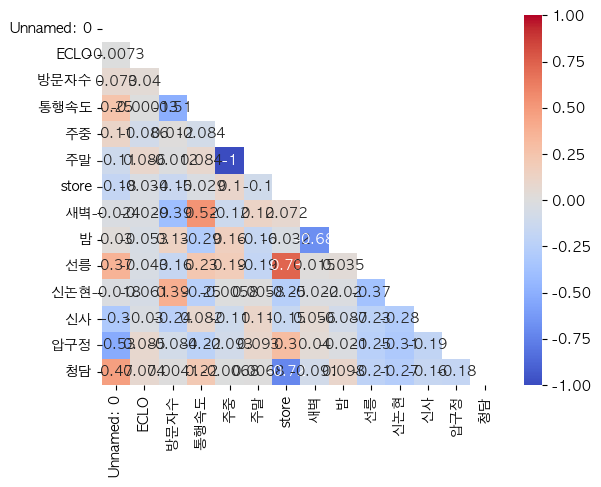

In [84]:
import seaborn as sns

corr = df.corr()

mask= np.triu(np.ones_like(corr))
sns.heatmap(corr, annot = True, cmap="coolwarm", vmax=1, vmin = -1, mask= mask)
